# Specific Stock Simulation


In [1]:
import matplotlib.pyplot as plt
import analysis_interfaces.interface_specific_stock as iss


## Block 1: Parameters


In [2]:
ticker = "RIO.L"
initial_funds = 100
include_fundamentals = True
include_sentiment = False  # True requires API keys and adds latency

period = "3mo"  # Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max

## Block 4: Simulate Daily Buy/Sell/Hold Strategy


In [3]:
df_pred = iss.build_prediction_and_stats(
            ticker,
            include_sentiment=include_sentiment,
            period=period,
        )

In [4]:
simulation_result = iss.simulate_prediction_signal_strategy(
    df_pred,
    initial_funds=initial_funds,
)


## Block 5: Portfolio Summary


In [5]:
df_pred

,Date,Open,High,Low,Close,Adj Close,Volume,TICKER,SMA10,SMA20,...,Daily Gain/Loss,technical_analysis_buy_score,technical_analysis_sell_score,fundamental_snapshot_report_date,fundamental_snapshot_available_from,fundamental_analysis_score,sentiment_analysis_score,multifactor_analysis_score,Signal,Signal_Text
0,2026-03-16,6647.329102,6798.0,6625.000000,6694.0,6694.000000,1876414,RIO.L,6829.3,7044.15,...,46.670898,0.10,-0.75,2025-12-31,2026-02-14,0.200,0.0,0.13125,-0.103188,WEAK SELL
1,2026-03-13,6811.000000,6835.0,6663.800781,6665.0,6665.000000,2454711,RIO.L,6893.5,7065.00,...,-146.000000,0.35,-0.50,2025-12-31,2026-02-14,0.200,0.0,0.13125,0.061812,HOLD
2,2026-03-12,6799.000000,6927.0,6761.000000,6845.0,6845.000000,2750197,RIO.L,6960.5,7091.10,...,46.000000,0.15,-0.60,2025-12-31,2026-02-14,0.200,0.0,0.13125,-0.037188,HOLD
3,2026-03-11,6808.000000,6843.0,6722.000000,6791.0,6791.000000,3332128,RIO.L,7004.2,7109.40,...,-17.000000,0.15,-0.60,2025-12-31,2026-02-14,0.200,0.0,0.13125,-0.037188,HOLD
4,2026-03-10,6701.000000,6844.0,6670.000000,6837.0,6837.000000,3529462,RIO.L,7071.2,7133.80,...,136.000000,0.25,-0.60,2025-12-31,2026-02-14,0.200,0.0,0.13125,-0.004188,HOLD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,2025-12-22,5872.000000,5967.0,5856.000000,5931.0,5928.904785,3162349,RIO.L,NaN,NaN,...,59.000000,0.35,-0.20,2025-06-30,2025-08-14,0.475,0.0,0.15500,0.262150,WEAK BUY
58,2025-12-19,5791.000000,5851.0,5765.000000,5838.0,5835.937500,5817202,RIO.L,NaN,NaN,...,47.000000,0.40,-0.15,2025-06-30,2025-08-14,0.475,0.0,0.15500,0.295150,WEAK BUY
59,2025-12-18,5773.000000,5801.0,5733.588867,5791.0,5788.954102,2235214,RIO.L,NaN,NaN,...,18.000000,0.35,-0.20,2025-06-30,2025-08-14,0.475,0.0,0.15500,0.262150,WEAK BUY
60,2025-12-17,5690.000000,5812.0,5681.000000,5753.0,5750.967773,6056594,RIO.L,NaN,NaN,...,63.000000,0.40,-0.15,2025-06-30,2025-08-14,0.475,0.0,0.14750,0.292675,WEAK BUY


In [6]:
simulation_result["transactions"]


,Date,action,signal_text,trade_price,units,trade_value,cash_balance,units_held,portfolio_value
0,2025-12-16,BUY,WEAK BUY,5659.500000,0.000883,5.000000,95.000000,0.000883,100.003092
1,2025-12-17,BUY,WEAK BUY,5721.500000,0.000874,5.000000,90.000000,0.001757,100.110132
2,2025-12-18,BUY,WEAK BUY,5782.000000,0.000865,5.000000,85.000000,0.002622,100.184695
3,2025-12-19,BUY,WEAK BUY,5814.500000,0.000860,5.000000,80.000000,0.003482,100.328143
4,2025-12-22,BUY,WEAK BUY,5901.500000,0.000847,5.000000,75.000000,0.004329,100.676966
5,2025-12-23,BUY,WEAK BUY,5958.500000,0.000839,5.000000,70.000000,0.005168,100.995005
6,2025-12-24,BUY,WEAK BUY,5987.000000,0.000835,5.000000,65.000000,0.006004,100.913303
7,2025-12-29,BUY,WEAK BUY,5970.000000,0.000838,5.000000,60.000000,0.006841,100.704439
8,2025-12-30,BUY,WEAK BUY,5999.000000,0.000833,5.000000,55.000000,0.007675,101.246865
9,2025-12-31,BUY,WEAK BUY,5984.500000,0.000835,5.000000,50.000000,0.008510,101.009216


In [7]:
simulation_result["summary"]


,start_date,end_date,initial_funds,ending_cash_balance,units_held,average_cost_per_unit,latest_close,holdings_value,total_portfolio_value,profit_loss,profit_loss_pct,buy_transactions,sell_transactions
0,2025-12-16,2026-03-16,100.0,5.538043,0.015774,6022.582567,6694.0,105.590914,111.128958,11.128958,11.128958,20,1


## Block 6: Consolidated Chart


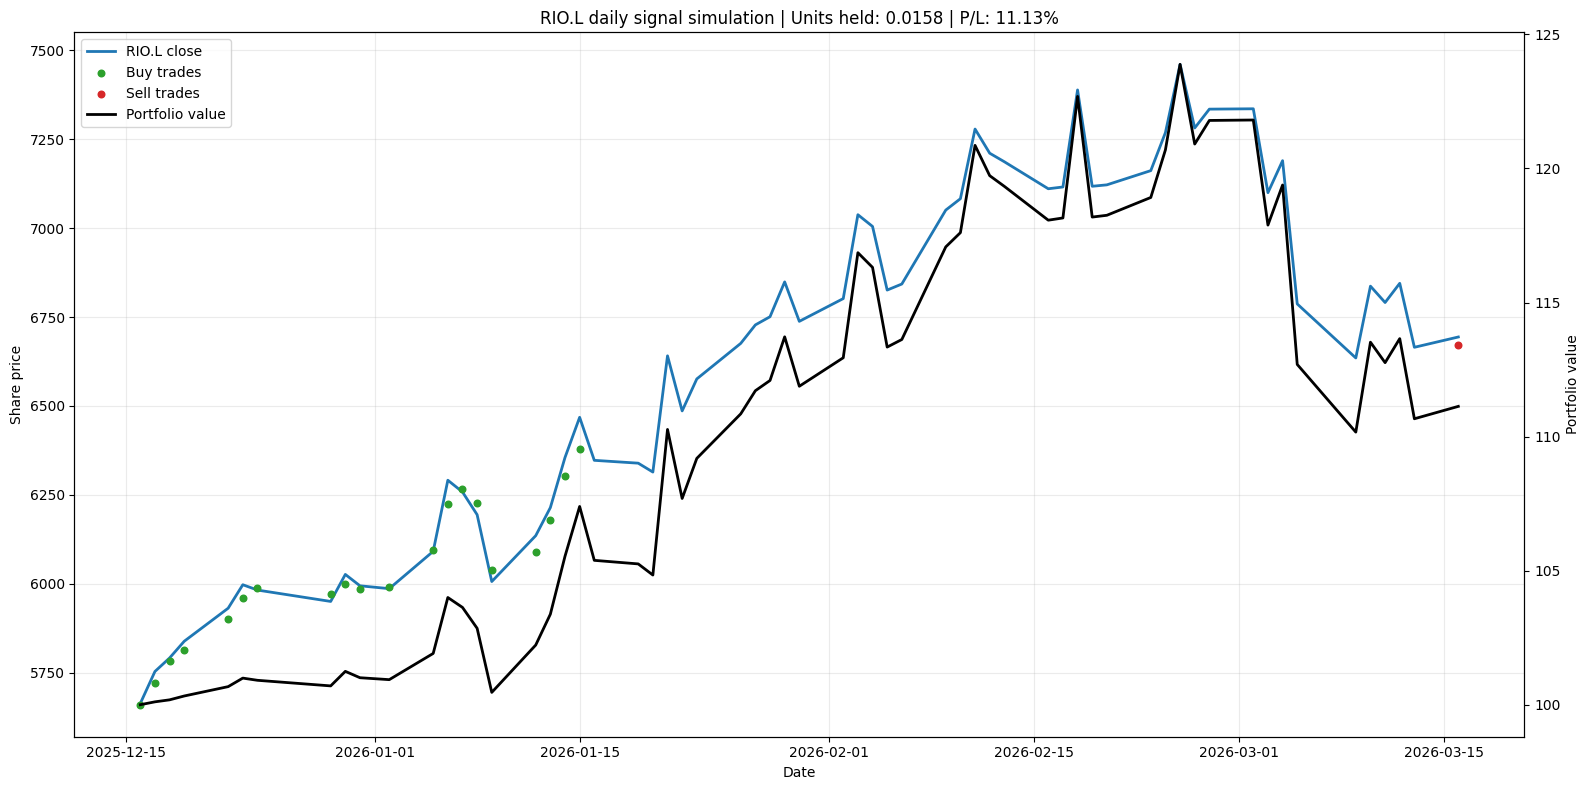

In [8]:
price_history = simulation_result["price_history"].copy()
daily_history = simulation_result["daily_history"].copy()
transactions = simulation_result["transactions"].copy()
simulation_summary = simulation_result["summary"].iloc[0]

buy_txns = transactions[transactions["action"] == "BUY"].copy()
sell_txns = transactions[transactions["action"] == "SELL"].copy()

fig, ax_price = plt.subplots(figsize=(16, 8))
ax_price.plot(
    price_history["Date"],
    price_history["Close"],
    color="#1f77b4",
    linewidth=2,
    label=f"{ticker} close",
)

if not buy_txns.empty:
    ax_price.scatter(
        buy_txns["Date"],
        buy_txns["trade_price"],
        color="#2ca02c",
        marker=".",
        s=90,
        label="Buy trades",
        zorder=5,
    )

if not sell_txns.empty:
    ax_price.scatter(
        sell_txns["Date"],
        sell_txns["trade_price"],
        color="#d62728",
        marker=".",
        s=90,
        label="Sell trades",
        zorder=5,
    )

ax_price.set_xlabel("Date")
ax_price.set_ylabel("Share price")
ax_price.grid(alpha=0.25)

ax_portfolio = ax_price.twinx()
ax_portfolio.plot(
    daily_history["Date"],
    daily_history["portfolio_value"],
    color="#000000",
    linewidth=2,
    label="Portfolio value",
)
ax_portfolio.set_ylabel("Portfolio value")

title = (
    f"{ticker} daily signal simulation | "
    f"Units held: {simulation_summary['units_held']:.4f} | "
    f"P/L: {simulation_summary['profit_loss_pct']:.2f}%"
)
ax_price.set_title(title)

handles_price, labels_price = ax_price.get_legend_handles_labels()
handles_portfolio, labels_portfolio = ax_portfolio.get_legend_handles_labels()
ax_price.legend(handles_price + handles_portfolio, labels_price + labels_portfolio, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Block 7: Daily Portfolio History


In [9]:
simulation_result["daily_history"][[
    "Date",
    "signal_text",
    "action",
    "trade_units",
    "trade_value",
    "cash_balance",
    "units_held",
    "holdings_value",
    "portfolio_value",
    "profit_loss_pct",
]]


,Date,signal_text,action,trade_units,trade_value,cash_balance,units_held,holdings_value,portfolio_value,profit_loss_pct
0,2025-12-16,WEAK BUY,BUY,0.000883,5.000000,95.000000,0.000883,5.003092,100.003092,0.003092
1,2025-12-17,WEAK BUY,BUY,0.000874,5.000000,90.000000,0.001757,10.110132,100.110132,0.110132
2,2025-12-18,WEAK BUY,BUY,0.000865,5.000000,85.000000,0.002622,15.184695,100.184695,0.184695
3,2025-12-19,WEAK BUY,BUY,0.000860,5.000000,80.000000,0.003482,20.328143,100.328143,0.328143
4,2025-12-22,WEAK BUY,BUY,0.000847,5.000000,75.000000,0.004329,25.676966,100.676966,0.676966
...,...,...,...,...,...,...,...,...,...,...
57,2026-03-10,HOLD,HOLD,0.000000,0.000000,0.000000,0.016604,113.522728,113.522728,13.522728
58,2026-03-11,HOLD,HOLD,0.000000,0.000000,0.000000,0.016604,112.758936,112.758936,12.758936
59,2026-03-12,HOLD,HOLD,0.000000,0.000000,0.000000,0.016604,113.655561,113.655561,13.655561
60,2026-03-13,HOLD,HOLD,0.000000,0.000000,0.000000,0.016604,110.666810,110.666810,10.666810
